In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pickle
import json
from datetime import datetime

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Masking, Bidirectional, LSTM, Dense, Dropout,
    Lambda, Subtract, Multiply, concatenate
)
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [4]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ── Environment Setup (Kaggle/Local) ─────────────────────────────────────────
IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    # Ganti sesuai nama dataset Kaggle Anda
    DATA_DIR     = "/kaggle/input/datasets/harimurtiadi/augmentasi-embedding-injection-coba"   # input data
    OUT_DIR      = "/kaggle/working"                 # output artifacts
    print("Environment : Kaggle")
else:
    DATA_DIR = os.getcwd()
    OUT_DIR  = os.getcwd()
    print("Environment : Local")

print(f"Data dir    : {DATA_DIR}")
print(f"Output dir  : {OUT_DIR}")


# ── GPU Info ──────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow  : {tf.__version__}")
print(f"Optuna      : {optuna.__version__}")
print(f"GPU tersedia: {len(gpus)}")

if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
            print(" ", g)
    except RuntimeError as e:
        print(e)

Environment : Kaggle
Data dir    : /kaggle/input/datasets/harimurtiadi/augmentasi-embedding-injection-coba
Output dir  : /kaggle/working
TensorFlow  : 2.19.0
Optuna      : 4.7.0
GPU tersedia: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# ── Load Data ─────────────────────────────────────────────────────────────────
def resolve_file_path(filename):
    """Cari file di DATA_DIR dulu, fallback ke OUT_DIR lalu cwd."""
    candidates = [
        os.path.join(DATA_DIR, filename),
        os.path.join(OUT_DIR, filename),
        os.path.join(os.getcwd(), filename),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"File '{filename}' tidak ditemukan di: {candidates}")


print("Loading embeddings...")
raw_q_emb  = np.load(resolve_file_path('final_questions_emb.npy'))
raw_ak_emb = np.load(resolve_file_path('final_answerkeys_emb.npy'))
answers_emb = np.load(resolve_file_path('final_answers_emb.npy'))

print("Loading metadata...")
metadata_path = resolve_file_path('final_metadata.pkl')
metadata = pd.read_pickle(metadata_path).reset_index(drop=True)

# Handle 2 format:
# 1) full per-sample embeddings (len == len(metadata))
# 2) compact per-IDPSJ embeddings (len == jumlah IDPSJ unik), perlu rekonstruksi via psj_idx
if len(raw_q_emb) == len(metadata) and len(raw_ak_emb) == len(metadata):
    questions_emb = raw_q_emb
    answerkeys_emb = raw_ak_emb
else:
    if 'psj_idx' not in metadata.columns:
        idpsj_sorted = sorted(metadata['IDPSJ'].unique())
        idpsj_to_idx = {psj: i for i, psj in enumerate(idpsj_sorted)}
        metadata['psj_idx'] = metadata['IDPSJ'].map(idpsj_to_idx)

    max_psj_idx = int(metadata['psj_idx'].max())
    if max_psj_idx >= len(raw_q_emb) or max_psj_idx >= len(raw_ak_emb):
        raise ValueError(
            f"psj_idx di metadata melebihi ukuran embedding kompak. "
            f"max psj_idx={max_psj_idx}, q_emb={len(raw_q_emb)}, ak_emb={len(raw_ak_emb)}"
        )

    questions_emb = raw_q_emb[metadata['psj_idx'].values]
    answerkeys_emb = raw_ak_emb[metadata['psj_idx'].values]

print("=== Hasil Load ===")
print(f"raw_q_emb      : {raw_q_emb.shape}")
print(f"raw_ak_emb     : {raw_ak_emb.shape}")
print(f"questions_emb  : {questions_emb.shape}")
print(f"answerkeys_emb : {answerkeys_emb.shape}")
print(f"answers_emb    : {answers_emb.shape}")
print(f"\nMetadata       : {len(metadata)} rows")
print(f"Kolom metadata : {list(metadata.columns)}")
print(f"Source metadata: {metadata_path}")

assert len(metadata) == len(answers_emb), \
    f"Mismatch: metadata={len(metadata)}, answers_emb={len(answers_emb)}"
assert len(metadata) == len(questions_emb), \
    f"Mismatch: metadata={len(metadata)}, questions_emb={len(questions_emb)}"
assert len(metadata) == len(answerkeys_emb), \
    f"Mismatch: metadata={len(metadata)}, answerkeys_emb={len(answerkeys_emb)}"

print(f"\nIDPSJ unik     : {sorted(metadata['IDPSJ'].unique())}")
print(f"Grade range    : {metadata['grade'].min()} - {metadata['grade'].max()}")

required_idpsj = [1, 9]
available_idpsj = set(metadata['IDPSJ'].unique())
for psj in required_idpsj:
    if psj not in available_idpsj:
        raise ValueError(f"IDPSJ {psj} tidak ditemukan dalam dataset")
    print(f"IDPSJ {psj}: {(metadata['IDPSJ'] == psj).sum()} samples")

print("\nDistribusi grade:")
print(metadata['grade'].value_counts().sort_index())


Loading embeddings...
Loading metadata...
=== Hasil Load ===
questions_emb  : (12, 135, 300)
answerkeys_emb : (12, 110, 300)
answers_emb    : (1743, 115, 300)

Metadata       : 1743 rows
Kolom metadata : ['IDJwb', 'IDPSJ', 'grade', 'psj_idx']
Source metadata: /kaggle/input/datasets/harimurtiadi/augmentasi-embedding-injection-coba/final_metadata.pkl

IDPSJ unik     : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Grade range    : 1 - 10
IDPSJ 1: 214 samples
IDPSJ 9: 263 samples

Distribusi grade:
grade
1     175
2     177
3     163
4     161
5     157
6     167
7     169
8     170
9     163
10    241
Name: count, dtype: int64


In [ ]:
# ── Split Train/Val/Test ─────────────────────────────────────────────────────
TEST_IDPSJ = 1
VAL_IDPSJ = 9

mask_test = metadata['IDPSJ'] == TEST_IDPSJ
mask_val = metadata['IDPSJ'] == VAL_IDPSJ
mask_train = ~(mask_test | mask_val)

X_q_train = questions_emb[mask_train]
X_ak_train = answerkeys_emb[mask_train]
X_a_train = answers_emb[mask_train]
y_train = metadata.loc[mask_train, 'grade'].values

X_q_val = questions_emb[mask_val]
X_ak_val = answerkeys_emb[mask_val]
X_a_val = answers_emb[mask_val]
y_val = metadata.loc[mask_val, 'grade'].values

X_q_test = questions_emb[mask_test]
X_ak_test = answerkeys_emb[mask_test]
X_a_test = answers_emb[mask_test]
y_test = metadata.loc[mask_test, 'grade'].values

print("\nSplit summary:")
print(f"  Train: {len(y_train)} samples")
print(f"  Val  : {len(y_val)} samples (IDPSJ={VAL_IDPSJ})")
print(f"  Test : {len(y_test)} samples (IDPSJ={TEST_IDPSJ})")


In [12]:
def build_siamese_bilstm_model(
    q_seq_len,
    ak_seq_len,
    a_seq_len,
    emb_dim=300,
    bilstm_units=128,
    dropout=0.3,
    learning_rate=1e-3,
    optimizer_type='adam'
):
    """
    Membangun Siamese BiLSTM model untuk question-answer grading.
    
    Architecture:
    - bilstm_question: BiLSTM dedicated untuk question
    - shared_bilstm: BiLSTM shared untuk answerkey dan answer
    - Features: [eq, ea, eak, |eak-ea|, eak⊙ea] → 5×256D = 1280D (after BiLSTM)
    - Dense layers: 256 → Dropout → 64 → 1 (regression)
    
    Parameters:
    -----------
    bilstm_units : int
        Number of units dalam each LSTM layer (akan menjadi 2x untuk bidirectional)
    dropout : float
        Dropout rate setelah dense 256
    learning_rate : float
        Learning rate untuk optimizer
    optimizer_type : str
        Tipe optimizer: 'adam', 'sgd', 'rmsprop'
    """
    
    # Bilstm layers
    bilstm_question = Bidirectional(
        LSTM(bilstm_units, return_sequences=False),
        name='bilstm_question'
    )
    shared_bilstm = Bidirectional(
        LSTM(bilstm_units, return_sequences=False),
        name='shared_bilstm'
    )
    
    # Input layers
    inp_q  = Input(shape=(q_seq_len, emb_dim), name='inp_q')
    inp_ak = Input(shape=(ak_seq_len, emb_dim), name='inp_ak')
    inp_a  = Input(shape=(a_seq_len, emb_dim), name='inp_a')
    
    # Masking
    # msk_q  = Masking(mask_value=0.0, name='msk_q')(inp_q)
    # msk_ak = Masking(mask_value=0.0, name='msk_ak')(inp_ak)
    # msk_a  = Masking(mask_value=0.0, name='msk_a')(inp_a)
    
    # Encoding
    eq  = bilstm_question(inp_q)           # shape: (batch, 2*bilstm_units)
    eak = shared_bilstm(inp_ak)            # shape: (batch, 2*bilstm_units)
    ea  = shared_bilstm(inp_a)             # shape: (batch, 2*bilstm_units)
    
    # Feature engineering
    diff     = Subtract(name='diff')([eak, ea])
    abs_diff = Lambda(lambda x: tf.abs(x), name='abs_diff')(diff)
    had_prod = Multiply(name='had_prod')([eak, ea])
    
    # Merge features
    merged = concatenate([eq, ea, eak, abs_diff, had_prod], name='merged')
    
    # Dense layers
    x = Dense(256, activation='relu', name='dense_256')(merged)
    x = Dropout(dropout, name='dropout')(x)
    x = Dense(64, activation='relu', name='dense_64')(x)
    out = Dense(1, activation='linear', name='output')(x)
    
    # Build model
    model = Model(inputs=[inp_q, inp_ak, inp_a], outputs=out, name='siamese_bilstm')
    
    # Compile dengan optimizer yang disesuaikan
    if optimizer_type.lower() == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_type.lower() == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_type.lower() == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'mse'])
    
    return model


# Test model builder
print("Testing model builder...")

# Tentukan seq_len otomatis dari data yang tersedia
if 'questions_emb' in globals() and 'answerkeys_emb' in globals() and 'answers_emb' in globals():
    Q_SEQ_LEN  = questions_emb.shape[1]
    AK_SEQ_LEN = answerkeys_emb.shape[1]
    A_SEQ_LEN  = answers_emb.shape[1]
elif 'X_q_train' in globals() and 'X_ak_train' in globals() and 'X_a_train' in globals():
    Q_SEQ_LEN  = X_q_train.shape[1]
    AK_SEQ_LEN = X_ak_train.shape[1]
    A_SEQ_LEN  = X_a_train.shape[1]
else:
    raise NameError("Q_SEQ_LEN/AK_SEQ_LEN/A_SEQ_LEN belum bisa dihitung. Load data dulu.")

test_model = build_siamese_bilstm_model(
    q_seq_len=Q_SEQ_LEN,
    ak_seq_len=AK_SEQ_LEN,
    a_seq_len=A_SEQ_LEN,
    bilstm_units=128,
    dropout=0.3,
    learning_rate=0.001
)
print("✓ Model created successfully")
print(f"  Model parameters: {test_model.count_params():,}")
# test_model.summary()
del test_model

Testing model builder...


I0000 00:00:1774340738.237015     122 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✓ Model created successfully
  Model parameters: 1,223,041


In [13]:
# ── Hyperparameter Config ─────────────────────────────────────────────────────
N_TRIALS = 40

TRIAL_CONFIG = {
    'bilstm_units': {
        'type': 'int',
        'low': 32,
        'high': 256,
        'step': 32,
        'description': 'Number of units in BiLSTM layer'
    },
    'dropout': {
        'type': 'float',
        'low': 0.10,
        'high': 0.50,
        'step': 0.05,
        'description': 'Dropout rate after dense_256'
    },
    'learning_rate': {
        'type': 'float',
        'low': 1e-4,
        'high': 1e-2,
        'log': True,
        'description': 'Learning rate optimizer (log scale)'
    },
    'optimizer_type': {
        'type': 'categorical',
        'choices': ['adam', 'sgd', 'rmsprop'],
        'description': 'Optimizer type'
    },

    # Fixed training params
    'batch_size': 32,
    'epochs': 100,
    'early_stopping_patience': 15,
    'reduce_lr_patience': 5,
    'reduce_lr_factor': 0.5,
}

print("=== Hyperparameter Search Space ===")
for key, cfg in TRIAL_CONFIG.items():
    if isinstance(cfg, dict) and 'type' in cfg:
        print(f"\n{key}")
        print(f"  type: {cfg['type']}")
        if cfg['type'] == 'int':
            print(f"  range: [{cfg['low']}, {cfg['high']}], step={cfg['step']}")
        elif cfg['type'] == 'float':
            if cfg.get('log', False):
                print(f"  range: [{cfg['low']:.2e}, {cfg['high']:.2e}] (log)")
            else:
                print(f"  range: [{cfg['low']}, {cfg['high']}], step={cfg.get('step', 'n/a')}")
        elif cfg['type'] == 'categorical':
            print(f"  choices: {cfg['choices']}")
        print(f"  desc: {cfg.get('description', '-')}")
    else:
        print(f"{key}: {cfg}")

print(f"\nPlanned trials: {N_TRIALS}")

=== Hyperparameter Search Space ===

bilstm_units
  type: int
  range: [32, 256], step=32
  desc: Number of units in BiLSTM layer

dropout
  type: float
  range: [0.1, 0.5], step=0.05
  desc: Dropout rate after dense_256

learning_rate
  type: float
  range: [1.00e-04, 1.00e-02] (log)
  desc: Learning rate optimizer (log scale)

optimizer_type
  type: categorical
  choices: ['adam', 'sgd', 'rmsprop']
  desc: Optimizer type
batch_size: 32
epochs: 100
early_stopping_patience: 15
reduce_lr_patience: 5
reduce_lr_factor: 0.5

Planned trials: 40


In [ ]:
# ── Optuna Objective + Study ──────────────────────────────────────────────────
from optuna.trial import TrialState

try:
    from optuna.integration import TFKerasPruningCallback
    HAS_PRUNING_CALLBACK = True
except Exception:
    HAS_PRUNING_CALLBACK = False

print(f"TFKerasPruningCallback available: {HAS_PRUNING_CALLBACK}")


def objective(trial):
    bilstm_units = trial.suggest_int(
        'bilstm_units',
        TRIAL_CONFIG['bilstm_units']['low'],
        TRIAL_CONFIG['bilstm_units']['high'],
        step=TRIAL_CONFIG['bilstm_units']['step']
    )
    dropout = trial.suggest_float(
        'dropout',
        TRIAL_CONFIG['dropout']['low'],
        TRIAL_CONFIG['dropout']['high'],
        step=TRIAL_CONFIG['dropout']['step']
    )
    learning_rate = trial.suggest_float(
        'learning_rate',
        TRIAL_CONFIG['learning_rate']['low'],
        TRIAL_CONFIG['learning_rate']['high'],
        log=TRIAL_CONFIG['learning_rate'].get('log', True)
    )
    optimizer_type = trial.suggest_categorical(
        'optimizer_type',
        TRIAL_CONFIG['optimizer_type']['choices']
    )

    try:
        model = build_siamese_bilstm_model(
            q_seq_len=Q_SEQ_LEN,
            ak_seq_len=AK_SEQ_LEN,
            a_seq_len=A_SEQ_LEN,
            bilstm_units=bilstm_units,
            dropout=dropout,
            learning_rate=learning_rate,
            optimizer_type=optimizer_type
        )

        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=TRIAL_CONFIG['early_stopping_patience'],
                restore_best_weights=True,
                verbose=0
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=TRIAL_CONFIG['reduce_lr_factor'],
                patience=TRIAL_CONFIG['reduce_lr_patience'],
                min_lr=1e-6,
                verbose=0
            )
        ]

        if HAS_PRUNING_CALLBACK:
            callbacks.append(TFKerasPruningCallback(trial, 'val_loss'))

        model.fit(
            [X_q_train, X_ak_train, X_a_train], y_train,
            validation_data=([X_q_val, X_ak_val, X_a_val], y_val),
            epochs=TRIAL_CONFIG['epochs'],
            batch_size=TRIAL_CONFIG['batch_size'],
            callbacks=callbacks,
            verbose=0
        )

        val_pred = model.predict([X_q_val, X_ak_val, X_a_val], verbose=0)
        val_mae = mean_absolute_error(y_val, val_pred)

        del model
        tf.keras.backend.clear_session()
        return val_mae

    except Exception as e:
        print(f"Trial error: {str(e)[:120]}")
        return float('inf')


print("\n=== STARTING OPTUNA BAYESIAN OPTIMIZATION ===")
sampler = TPESampler(seed=SEED, n_startup_trials=5)
pruner = MedianPruner()

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
    study_name='siamese_bilstm_hpo'
 )

print("Sampler  : TPE")
print("Pruner   : Median")
print("Objective: min validation MAE")
print(f"Trials   : {N_TRIALS}\n")

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n=== OPTIMIZATION COMPLETED ===")
best_trial = study.best_trial
print(f"Best trial: #{best_trial.number}")
print(f"Best val MAE: {best_trial.value:.6f}")
print("Best params:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

optuna_results = {
    'study': study,
    'best_trial': best_trial,
    'best_params': best_trial.params,
    'best_value': best_trial.value,
    'trials_df': study.trials_dataframe()
}

print(f"\nTotal trials: {len(study.trials)}")
print(f"Pruned      : {len([t for t in study.trials if t.state == TrialState.PRUNED])}")
print(f"Completed   : {len([t for t in study.trials if t.state == TrialState.COMPLETE])}")


[I 2026-03-24 08:27:39,119] A new study created in memory with name: siamese_bilstm_hpo


TFKerasPruningCallback available: False

=== STARTING OPTUNA BAYESIAN OPTIMIZATION ===
Sampler  : TPE
Pruner   : Median
Objective: min validation MAE
Trials   : 40



  0%|          | 0/40 [00:00<?, ?it/s]

Trial error: name 'X_q_train' is not defined
[I 2026-03-24 08:27:39,228] Trial 0 finished with value: inf and parameters: {'bilstm_units': 96, 'dropout': 0.5, 'learning_rate': 0.0029106359131330704, 'optimizer_type': 'adam'}. Best is trial 0 with value: inf.
Trial error: name 'X_q_train' is not defined
[I 2026-03-24 08:27:39,317] Trial 1 finished with value: inf and parameters: {'bilstm_units': 32, 'dropout': 0.45000000000000007, 'learning_rate': 0.0015930522616241021, 'optimizer_type': 'rmsprop'}. Best is trial 0 with value: inf.
Trial error: name 'X_q_train' is not defined
[I 2026-03-24 08:27:39,449] Trial 2 finished with value: inf and parameters: {'bilstm_units': 224, 'dropout': 0.15000000000000002, 'learning_rate': 0.0002310201887845295, 'optimizer_type': 'rmsprop'}. Best is trial 0 with value: inf.
Trial error: name 'X_q_train' is not defined
[I 2026-03-24 08:27:39,547] Trial 3 finished with value: inf and parameters: {'bilstm_units': 128, 'dropout': 0.2, 'learning_rate': 0.00167

AttributeError: module 'optuna' has no attribute 'TrialState'

AttributeError: module 'optuna' has no attribute 'TrialState'

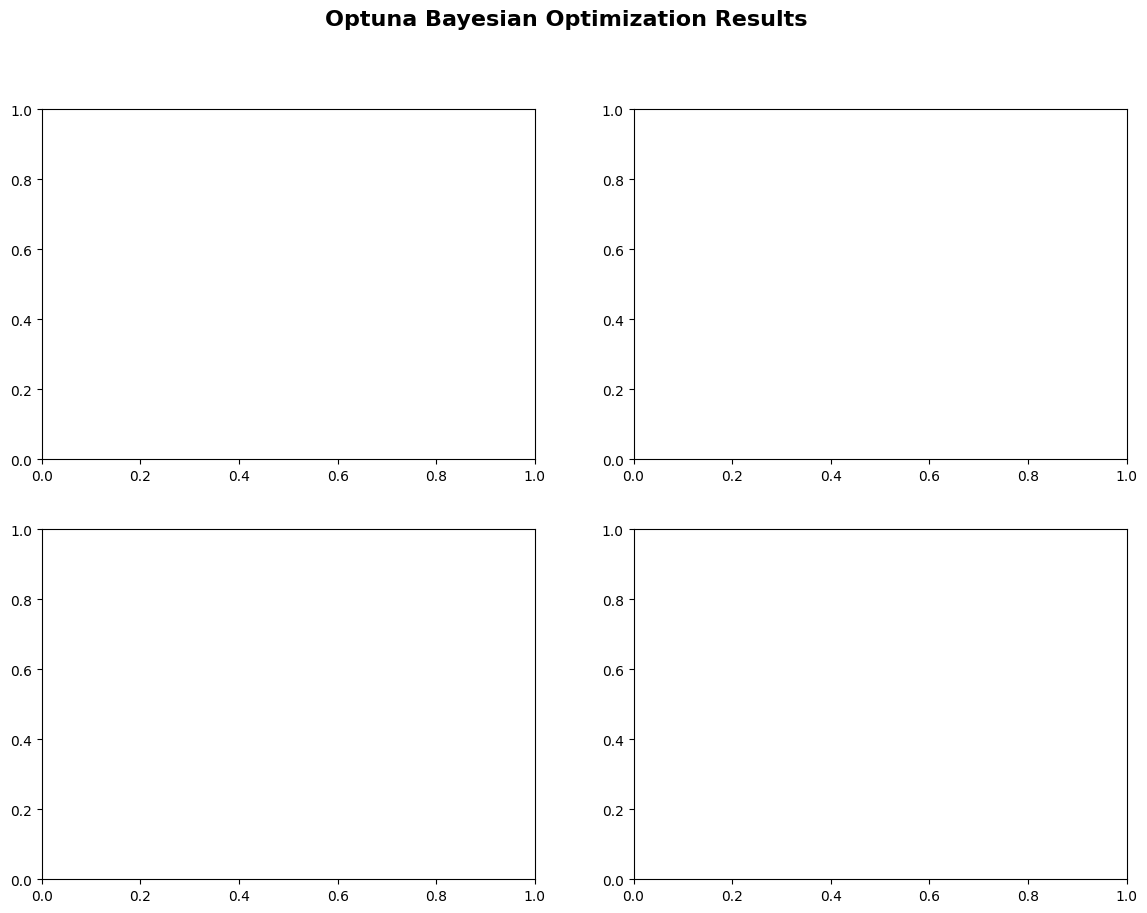

In [ ]:
# Extract trial history
from optuna.trial import TrialState

trials_df = study.trials_dataframe()

# 1. Optimization History
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Optuna Bayesian Optimization Results', fontsize=16, fontweight='bold')

# Plot 1: Optimization History (Best value over trials)
ax = axes[0, 0]
best_values = [study.trials[i].value if study.trials[i].state == TrialState.COMPLETE else float('inf') 
               for i in range(len(study.trials))]
best_values = [min(best_values[:i+1]) for i in range(len(best_values))]
ax.plot(best_values, marker='o', linestyle='-', label='Best MAE', color='blue')
ax.set_xlabel('Trial Number')
ax.set_ylabel('Validation MAE (lower is better)')
ax.set_title('Optimization History')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Distribution of learning_rate
ax = axes[0, 1]
learning_rates = [t.params.get('learning_rate', np.nan) for t in study.trials 
                  if t.state == TrialState.COMPLETE]
ax.hist(learning_rates, bins=15, edgecolor='black', alpha=0.7, color='green')
ax.set_xlabel('Learning Rate (log scale)')
ax.set_ylabel('Frequency')
ax.set_title('Learning Rate Distribution')
ax.set_xscale('log')

# Plot 3: Distribution of bilstm_units
ax = axes[1, 0]
bilstm_list = [t.params.get('bilstm_units', np.nan) for t in study.trials 
               if t.state == TrialState.COMPLETE]
ax.hist(bilstm_list, bins=10, edgecolor='black', alpha=0.7, color='orange')
ax.set_xlabel('BiLSTM Units')
ax.set_ylabel('Frequency')
ax.set_title('BiLSTM Units Distribution')

# Plot 4: Distribution of dropout
ax = axes[1, 1]
dropout_list = [t.params.get('dropout', np.nan) for t in study.trials 
                if t.state == TrialState.COMPLETE]
ax.hist(dropout_list, bins=10, edgecolor='black', alpha=0.7, color='red')
ax.set_xlabel('Dropout Rate')
ax.set_ylabel('Frequency')
ax.set_title('Dropout Rate Distribution')

plt.tight_layout()
os.makedirs(OUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUT_DIR, 'optuna_optimization_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'optuna_optimization_history.png'")

# 2. Parameter Importance (if available in Optuna)
print("\n" + "="*70)
print("PARAMETER IMPORTANCE ANALYSIS (from completed trials)")
print("="*70)

# Calculate correlation antara hyperparameter dan validation MAE
completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE]
if len(completed_trials) > 3:
    param_names = ['bilstm_units', 'dropout', 'learning_rate']
    importance_dict = {}
    
    for param_name in param_names:
        param_values = []
        mae_values = []
        
        for trial in completed_trials:
            if param_name in trial.params:
                param_values.append(trial.params[param_name])
                mae_values.append(trial.value)
        
        if len(param_values) > 3:
            # Calculate correlation
            correlation = np.corrcoef(param_values, mae_values)[0, 1]
            importance_dict[param_name] = abs(correlation) if not np.isnan(correlation) else 0
            print(f"\n{param_name}:")
            print(f"  Correlation with MAE: {correlation:.4f}")
            print(f"  Importance score: {abs(correlation):.4f}")
    
    # Rank by importance
    sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
    print("\n" + "-"*70)
    print("Parameter Importance Ranking:")
    for i, (param, score) in enumerate(sorted_importance, 1):
        print(f"  {i}. {param}: {score:.4f}")


In [ ]:
print("\n" + "="*70)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*70)

# Extract best parameters
best_params = study.best_trial.params
print(f"\nBest hyperparameters dari Optuna:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Build final model dengan best hyperparameters
print(f"\nBuilding final model...")
final_model = build_siamese_bilstm_model(
    q_seq_len=Q_SEQ_LEN,
    ak_seq_len=AK_SEQ_LEN,
    a_seq_len=A_SEQ_LEN,
    bilstm_units=best_params['bilstm_units'],
    dropout=best_params['dropout'],
    learning_rate=best_params['learning_rate'],
    optimizer_type=best_params['optimizer_type']
)

print(f"✓ Model created")
print(f"  Total parameters: {final_model.count_params():,}")

# Callbacks untuk final training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=TRIAL_CONFIG['early_stopping_patience'],
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=TRIAL_CONFIG['reduce_lr_factor'],
    patience=TRIAL_CONFIG['reduce_lr_patience'],
    min_lr=1e-6,
    verbose=1
)

# Train final model
print(f"\nTraining final model on training set with validation on IDPSJ 9...")
history = final_model.fit(
    [X_q_train, X_ak_train, X_a_train], y_train,
    validation_data=([X_q_val, X_ak_val, X_a_val], y_val),
    epochs=TRIAL_CONFIG['epochs'],
    batch_size=TRIAL_CONFIG['batch_size'],
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate on validation set
print(f"\nEvaluation on Validation Set (IDPSJ 9):")
val_predictions = final_model.predict([X_q_val, X_ak_val, X_a_val], verbose=0)
val_mae = mean_absolute_error(y_val, val_predictions)
val_mse = mean_squared_error(y_val, val_predictions)
val_rmse = np.sqrt(val_mse)
val_mape = mean_absolute_percentage_error(y_val, val_predictions)

print(f"  MAE:  {val_mae:.6f}")
print(f"  MSE:  {val_mse:.6f}")
print(f"  RMSE: {val_rmse:.6f}")
print(f"  MAPE: {val_mape:.4f}")

# Evaluate on test set
print(f"\nEvaluation on Test Set (IDPSJ 1):")
test_predictions = final_model.predict([X_q_test, X_ak_test, X_a_test], verbose=0)
test_mae = mean_absolute_error(y_test, test_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
test_rmse = np.sqrt(test_mse)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)

print(f"  MAE:  {test_mae:.6f}")
print(f"  MSE:  {test_mse:.6f}")
print(f"  RMSE: {test_rmse:.6f}")
print(f"  MAPE: {test_mape:.4f}")

# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Final Model Training History (with Best Hyperparameters)', fontsize=14, fontweight='bold')

# Loss plot
ax = axes[0]
ax.plot(history.history['loss'], label='Train Loss', marker='o', markersize=3)
ax.plot(history.history['val_loss'], label='Validation Loss', marker='s', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Model Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# MAE plot
ax = axes[1]
ax.plot(history.history['mae'], label='Train MAE', marker='o', markersize=3)
ax.plot(history.history['val_mae'], label='Validation MAE', marker='s', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.set_title('Mean Absolute Error')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs(OUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUT_DIR, 'final_model_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Training history visualization saved as 'final_model_training_history.png'")

# Store final results
final_results = {
    'model': final_model,
    'history': history,
    'best_params': best_params,
    'val_metrics': {
        'mae': float(val_mae),
        'mse': float(val_mse),
        'rmse': float(val_rmse),
        'mape': float(val_mape)
    },
    'test_metrics': {
        'mae': float(test_mae),
        'mse': float(test_mse),
        'rmse': float(test_rmse),
        'mape': float(test_mape)
    }
}



TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

Best hyperparameters dari Optuna:
  bilstm_units: 96
  dropout: 0.5
  learning_rate: 0.0029106359131330704
  optimizer_type: adam

Building final model...
✓ Model created
  Total parameters: 872,321

Training final model on training set with validation on IDPSJ 9...


NameError: name 'X_q_train' is not defined